QUESTION 7: PERCEPTRON 
Seed: 42 | Accuracy: 100.00%
Weights: [0.57699256 0.11620439]
Bias: 0.5476885381006924



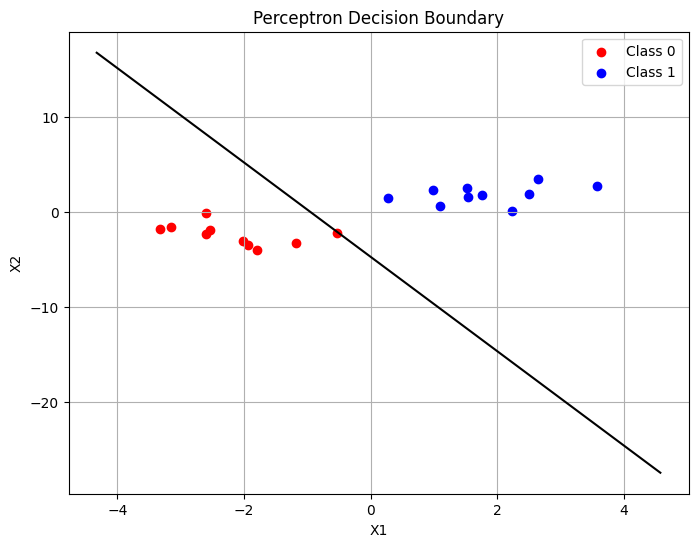

Seed: 123 | Accuracy: 100.00%
Weights: [1.53388250e-04 1.26479792e+00]
Bias: 0.16297849805199194



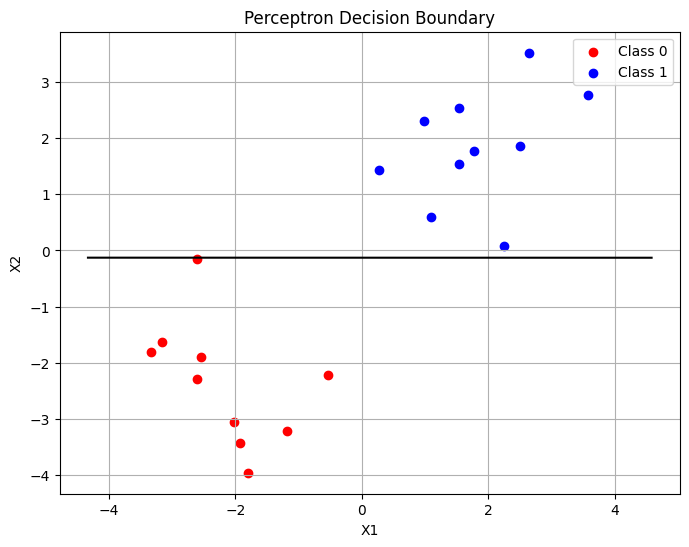

Seed: 456 | Accuracy: 100.00%
Weights: [0.17983499 0.24974544]
Bias: 0.47857582027543677



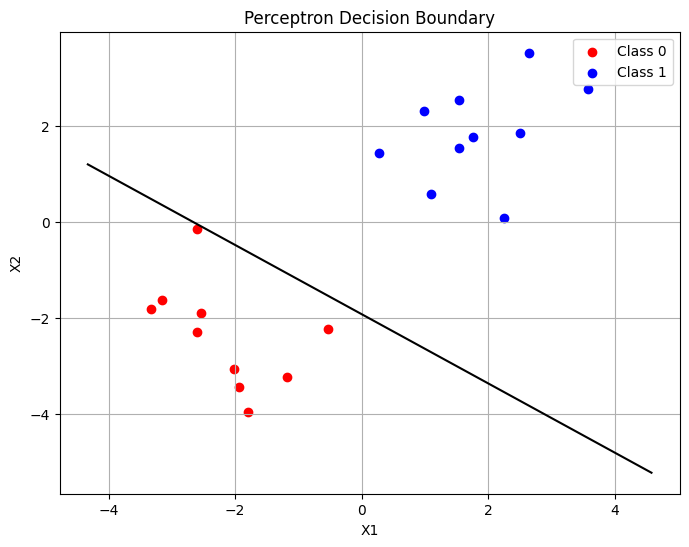

 QUESTION 8: NEURAL NETWORK 


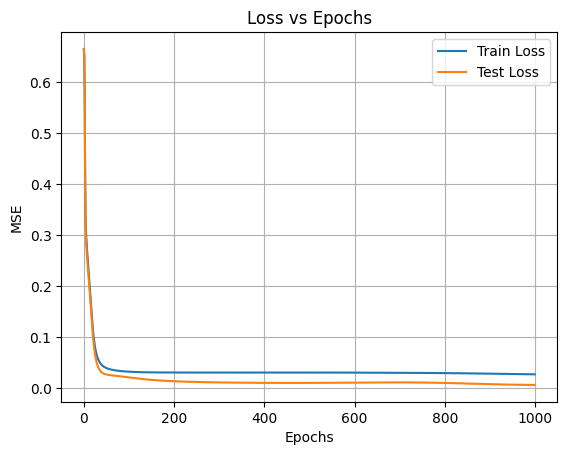

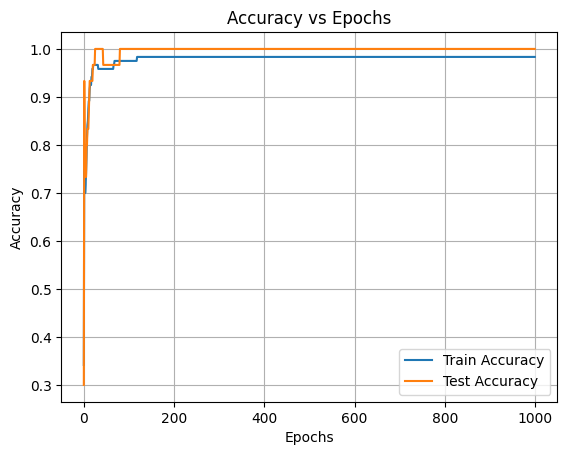

In [3]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# QUESTION 7
# PERCEPTRON

print("QUESTION 7: PERCEPTRON ")

# Load dataset
data = pd.read_csv('A5_P1.csv')
X = data[['X1', 'X2']].values
y = data['y'].values

# Ensure labels are {0,1}
y = np.where(y <= 0, 0, 1)


class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=20):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def initialize_weights(self, n_features):
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

    def step(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.initialize_weights(n_features)

        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                z = np.dot(x_i, self.weights) + self.bias
                y_pred = self.step(z)

                error = y[idx] - y_pred

                # Perceptron update
                self.weights += self.learning_rate * error * x_i
                self.bias += self.learning_rate * error

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step(z)

    def visualize(self, X, y):
        plt.figure(figsize=(8, 6))

        # Data points
        plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Class 0')
        plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')

        # Decision boundary: w1*x1 + w2*x2 + b = 0
        x_vals = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)
        y_vals = -(self.weights[0]*x_vals + self.bias) / self.weights[1]

        plt.plot(x_vals, y_vals, 'k-')

        plt.title("Perceptron Decision Boundary")
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.legend()
        plt.grid()
        plt.show()


# Run with multiple seeds
def run_perceptron(seed):
    np.random.seed(seed)

    model = Perceptron(learning_rate=0.01, n_iterations=20)
    model.fit(X, y)

    y_pred = model.predict(X)
    acc = np.mean(y_pred == y)

    print(f"Seed: {seed} | Accuracy: {acc*100:.2f}%")
    print(f"Weights: {model.weights}")
    print(f"Bias: {model.bias}\n")

    model.visualize(X, y)


seeds = [42, 123, 456]
for s in seeds:
    run_perceptron(s)


# QUESTION 8
# NEURAL NETWORK
print(" QUESTION 8: NEURAL NETWORK ")

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target


# One-hot encoding
def one_hot(y, num_classes):
    out = np.zeros((y.size, num_classes))
    out[np.arange(y.size), y] = 1
    return out


Y = one_hot(y, 3)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.lr = lr

        # Small random initialization
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def tanh(self, x):
        return np.tanh(x)

    def tanh_deriv(self, x):
        return 1 - np.tanh(x)**2

    def softmax(self, x):
        exp = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp / np.sum(exp, axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.tanh(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def loss(self, y, y_pred):
        return np.mean(np.sum((y - y_pred)**2, axis=1))

    def backward(self, X, y, output):
        m = X.shape[0]

        # Output layer
        delta2 = output - y

        dW2 = self.a1.T @ delta2 / m
        db2 = np.sum(delta2, axis=0, keepdims=True) / m

        # Hidden layer
        delta1 = (delta2 @ self.W2.T) * self.tanh_deriv(self.z1)

        dW1 = X.T @ delta1 / m
        db1 = np.sum(delta1, axis=0, keepdims=True) / m

        # Update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def accuracy(self, y, y_pred):
        return np.mean(np.argmax(y, axis=1) == np.argmax(y_pred, axis=1))

    def train(self, X_train, Y_train, X_test, Y_test, epochs=1000):
        train_loss, test_loss = [], []
        train_acc, test_acc = [], []

        for epoch in range(epochs):
            for i in range(X_train.shape[0]):
                x = X_train[i:i+1]
                y = Y_train[i:i+1]

                out = self.forward(x)
                self.backward(x, y, out)

            # Evaluation
            train_pred = self.forward(X_train)
            test_pred = self.forward(X_test)

            train_loss.append(self.loss(Y_train, train_pred))
            test_loss.append(self.loss(Y_test, test_pred))

            train_acc.append(self.accuracy(Y_train, train_pred))
            test_acc.append(self.accuracy(Y_test, test_pred))

        return train_loss, test_loss, train_acc, test_acc


# Train model
nn = NeuralNetwork(input_size=4, hidden_size=5, output_size=3, lr=0.01)

train_loss, test_loss, train_acc, test_acc = nn.train(
    X_train, Y_train, X_test, Y_test, epochs=1000
)

# Plot Loss
plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid()
plt.show()